In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("../data/processed/orders_flat.csv", parse_dates=["order_purchase_timestamp"])
delivered = orders[orders['order_status'] == 'delivered'].copy()

delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')


cohort_month = delivered.groupby('customer_unique_id')['order_month'].min().rename('cohort_month')
delivered = delivered.merge(cohort_month, on='customer_unique_id')


delivered['period_number'] = (
    (delivered['order_month'].dt.year - delivered['cohort_month'].dt.year) * 12
    + (delivered['order_month'].dt.month - delivered['cohort_month'].dt.month)
)

In [2]:
cohort_pivot_raw = delivered.groupby(['cohort_month', 'period_number'])['customer_unique_id'].nunique().unstack()
cohort_sizes = cohort_pivot_raw[0]
print(cohort_sizes.sort_index())

cohort_month
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M, Name: 0, dtype: float64


In [3]:
min_cohort_size = 30
valid_cohorts = cohort_sizes[cohort_sizes >= min_cohort_size].index
print(f"Giữ {len(valid_cohorts)}/{len(cohort_sizes)} cohort (loại các cohort < {min_cohort_size} khách)")

Giữ 21/23 cohort (loại các cohort < 30 khách)


In [ ]:
max_data_month = delivered['order_month'].max()
max_period = cohort_pivot_raw.columns.max()

cohort_pivot = cohort_pivot_raw.loc[valid_cohorts].reindex(columns=range(0, max_period + 1))


max_observable = pd.Series({
    c: (max_data_month.year - c.year) * 12 + (max_data_month.month - c.month)
    for c in cohort_pivot.index
})

counts_filled = cohort_pivot.copy()
for period in cohort_pivot.columns:
    observable_mask = max_observable >= period

    counts_filled.loc[observable_mask, period] = counts_filled.loc[observable_mask, period].fillna(0)

    counts_filled.loc[~observable_mask, period] = np.nan

retention_pct = counts_filled.divide(cohort_sizes.loc[valid_cohorts], axis=0) * 100

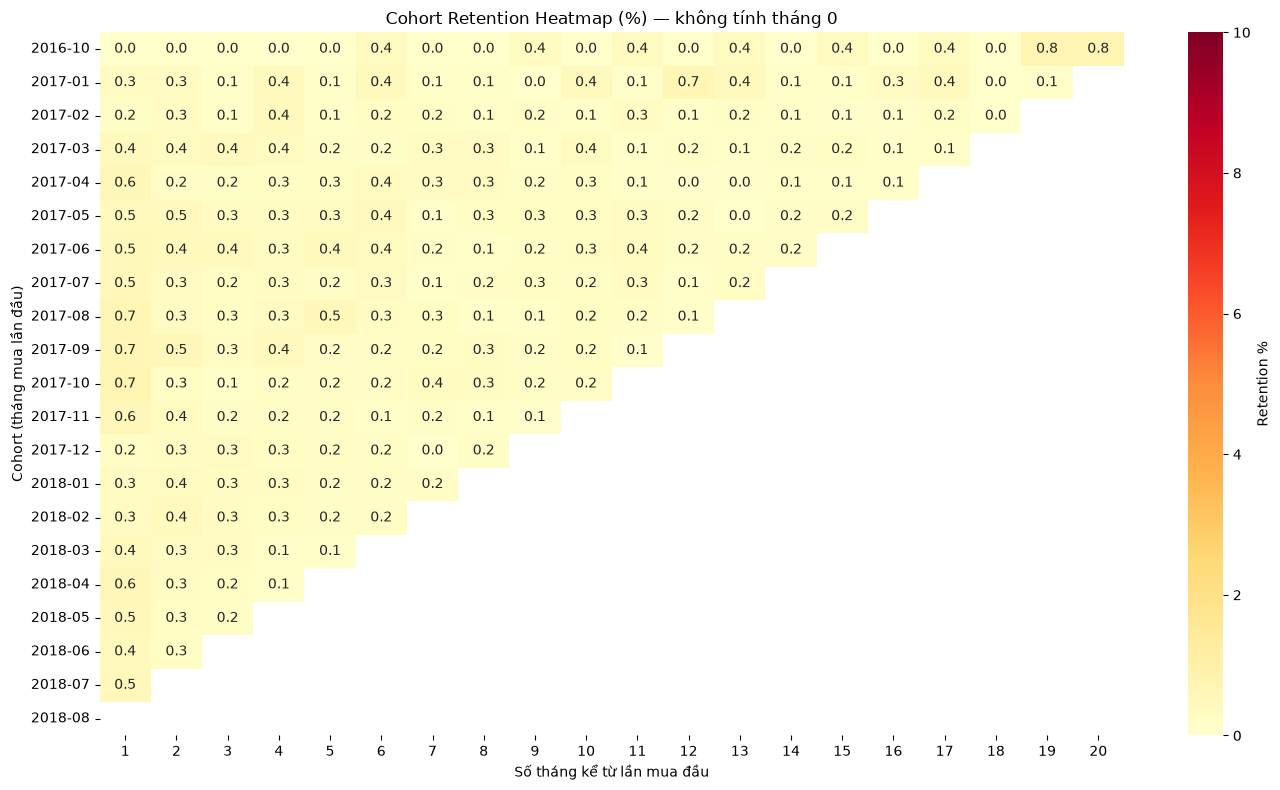

In [5]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_pct.drop(columns=0),
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    vmin=0, vmax=10,     # thu hẹp scale vì retention thực tế rất thấp (<10%)
    mask=retention_pct.drop(columns=0).isna(),
    cbar_kws={'label': 'Retention %'}
)
plt.title('Cohort Retention Heatmap (%) — không tính tháng 0')
plt.xlabel('Số tháng kể từ lần mua đầu')
plt.ylabel('Cohort (tháng mua lần đầu)')
plt.tight_layout()
plt.savefig('../reports/figures/14_cohort_retention_heatmap.png', dpi=150)
plt.show()

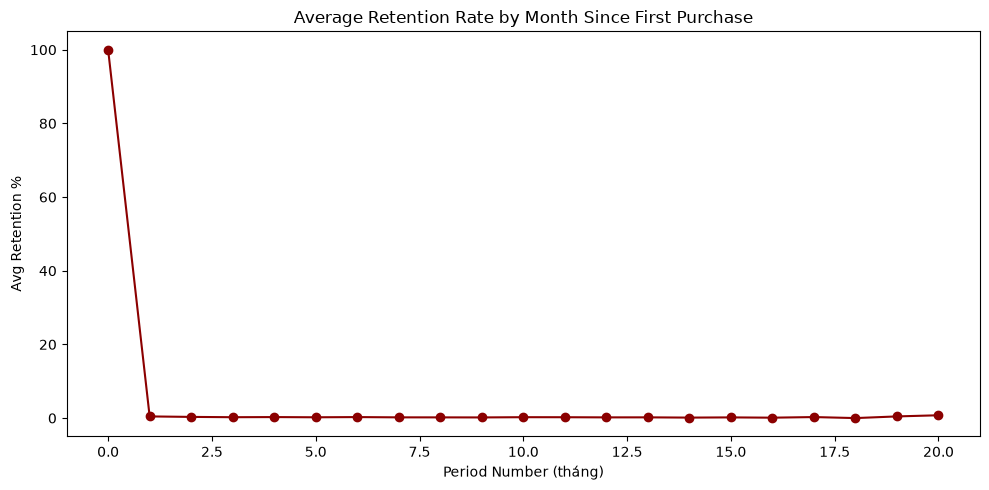

period_number
0    100.00
1      0.45
2      0.32
3      0.24
4      0.27
5      0.22
6      0.27
dtype: float64


In [6]:
avg_retention_by_period = retention_pct.mean(axis=0, skipna=True)

plt.figure(figsize=(10, 5))
avg_retention_by_period.plot(marker='o', color='darkred')
plt.title('Average Retention Rate by Month Since First Purchase')
plt.xlabel('Period Number (tháng)')
plt.ylabel('Avg Retention %')
plt.tight_layout()
plt.savefig('../reports/figures/15_avg_retention_curve.png', dpi=150)
plt.show()

print(avg_retention_by_period.head(7).round(2))

In [ ]:
cohort_month_per_customer = delivered.groupby('customer_unique_id')['cohort_month'].first()
max_observable_per_customer = cohort_month_per_customer.apply(
    lambda c: (max_data_month.year - c.year) * 12 + (max_data_month.month - c.month)
)

eligible_customer_ids = max_observable_per_customer[max_observable_per_customer >= 6].index
total_eligible = len(eligible_customer_ids)

repeated_within_6m = delivered[
    delivered['customer_unique_id'].isin(eligible_customer_ids) &
    delivered['period_number'].between(1, 6)
]['customer_unique_id'].nunique()

cumulative_repeat_rate_6m = repeated_within_6m / total_eligible * 100
print(f"Khách đủ điều kiện quan sát (>=6 tháng): {total_eligible:,}")
print(f"Cumulative repeat rate (tháng 1-6): {cumulative_repeat_rate_6m:.2f}%")
print(f"So sánh với Giai đoạn 5 (repeat_within_180d): ~2.8%")

Khách đủ điều kiện quan sát (>=6 tháng): 55,525
Cumulative repeat rate (tháng 1-6): 1.75%
So sánh với Giai đoạn 5 (repeat_within_180d): ~2.8%


In [ ]:
orders_in_period0 = delivered[
    delivered['customer_unique_id'].isin(eligible_customer_ids) &
    (delivered['period_number'] == 0)
]

same_month_repeat_count = orders_in_period0.groupby('customer_unique_id')['order_id'].nunique()
hidden_repeats = (same_month_repeat_count > 1).sum()

print(f"Khách mua lại ngay trong cùng tháng với đơn đầu (bị ẩn ở period 0): {hidden_repeats:,}")

corrected_rate = (repeated_within_6m + hidden_repeats) / total_eligible * 100
print(f"Cumulative repeat rate đã hiệu chỉnh: {corrected_rate:.2f}%")

Khách mua lại ngay trong cùng tháng với đơn đầu (bị ẩn ở period 0): 863
Cumulative repeat rate đã hiệu chỉnh: 3.31%


In [ ]:
cohort_sizes_df = cohort_sizes.loc[valid_cohorts].rename('cohort_size').reset_index()
cohort_sizes_df.columns = ['cohort_month', 'cohort_size']
cohort_sizes_df['cohort_month'] = cohort_sizes_df['cohort_month'].astype(str)

cohort_long = retention_pct.reset_index().melt(
    id_vars='cohort_month', var_name='period_number', value_name='retention_pct'
)
cohort_long['cohort_month'] = cohort_long['cohort_month'].astype(str)
cohort_long = cohort_long.merge(cohort_sizes_df, on='cohort_month', how='left')

cohort_long.to_csv('../data/processed/cohort_retention_long.csv', index=False)
print(cohort_long.head())

  cohort_month period_number  retention_pct  cohort_size
0      2016-10             0          100.0        262.0
1      2017-01             0          100.0        717.0
2      2017-02             0          100.0       1628.0
3      2017-03             0          100.0       2503.0
4      2017-04             0          100.0       2256.0
